# Autoencoder Anomaly Detection Pipeline

Autoencoders are neural networks designed to compress inputs into a bottleneck layer (encoder) and reconstruct the inputs from this bottleneck (decoder). When trained solely on normal data, the model learns to reconstruct normal patterns accurately. When anomalous data points are processed, the model produces elevated reconstruction errors, exposing anomalies.



In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

# Generate synthetic normal signal sequences (sine waves + noise)
np.random.seed(77)
n_samples = 600
seq_len = 64

t = np.linspace(0, 4*np.pi, seq_len)
normal_signals = []
for _ in range(n_samples):
    phase = np.random.uniform(0, 2*np.pi)
    amplitude = np.random.uniform(0.8, 1.2)
    noise = np.random.normal(0, 0.08, seq_len)
    signal = amplitude * np.sin(t + phase) + noise
    normal_signals.append(signal)

normal_signals = np.array(normal_signals, dtype=np.float32)

# Convert to PyTorch tensors
X = torch.FloatTensor(normal_signals)
print(f"Dataset shape: {X.shape} (Samples x Features)")



Dataset shape: torch.Size([600, 64]) (Samples x Features)


## Autoencoder Network Architecture

We implement the Autoencoder in PyTorch:
1. **Encoder**: Compresses the 64-dimensional sequence into an 8-dimensional latent vector.
2. **Decoder**: Reconstructs the 64-dimensional output from the latent vector.



In [2]:
class Autoencoder(nn.Module):
    def __init__(self, input_dim, latent_dim):
        super(Autoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.ReLU(),
            nn.Linear(32, latent_dim),
            nn.ReLU()
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 32),
            nn.ReLU(),
            nn.Linear(32, input_dim)
        )
        
    def forward(self, x):
        latent = self.encoder(x)
        reconstructed = self.decoder(latent)
        return reconstructed

input_dim = seq_len
latent_dim = 8

model = Autoencoder(input_dim, latent_dim)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)



## Training on Normal Signals

We train the autoencoder model for 30 epochs on our normal signal set.



In [3]:
epochs = 30
losses = []

for epoch in range(1, epochs + 1):
    outputs = model(X)
    loss = criterion(outputs, X)
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    losses.append(loss.item())
    if epoch % 10 == 0:
        print(f"Epoch {epoch:2d}/{epochs} | Reconstruction MSE Loss: {loss.item():.5f}")



Epoch 10/30 | Reconstruction MSE Loss: 0.30299
Epoch 20/30 | Reconstruction MSE Loss: 0.05064
Epoch 30/30 | Reconstruction MSE Loss: 0.02351


## Anomaly Testing & Reconstruction Loss Evaluation

We construct a test sample containing normal signals and two anomalous signals featuring sudden sharp noise spikes. We compute reconstruction losses and flag inputs exceeding the 97.5th percentile threshold.



In [4]:
# Define reconstruction threshold based on training set reconstruction error
model.eval()
with torch.no_grad():
    train_reconstructions = model(X)
    mse_per_sample = torch.mean((X - train_reconstructions)**2, dim=1).numpy()

threshold = np.percentile(mse_per_sample, 97.5)
print(f"Anomaly detection reconstruction threshold: {threshold:.5f}")

# Create test signals: 1 normal, 1 anomalous
test_normal = np.sin(t) + np.random.normal(0, 0.08, seq_len)
# Add anomaly: sharp local spike
test_anomalous = np.sin(t) + np.random.normal(0, 0.08, seq_len)
test_anomalous[25:30] += 2.5 # local spike anomaly

test_batch = torch.FloatTensor(np.array([test_normal, test_anomalous], dtype=np.float32))

with torch.no_grad():
    reconstructed_batch = model(test_batch).numpy()

# Calculate reconstruction losses
errors = np.mean((test_batch.numpy() - reconstructed_batch)**2, axis=1)
print(f"Normal sample reconstruction error:    {errors[0]:.5f}")
print(f"Anomalous sample reconstruction error: {errors[1]:.5f}")



Anomaly detection reconstruction threshold: 0.03392
Normal sample reconstruction error:    0.02562
Anomalous sample reconstruction error: 0.48262


## Telemetry Signal Reconstruction Plot

We visualize the original signal (blue) against its reconstruction (orange) for both test samples to demonstrate how the autoencoder fails to reconstruct the anomalous spikes.



<cell>:20: UserWarning:

FigureCanvasAgg is non-interactive, and thus cannot be shown



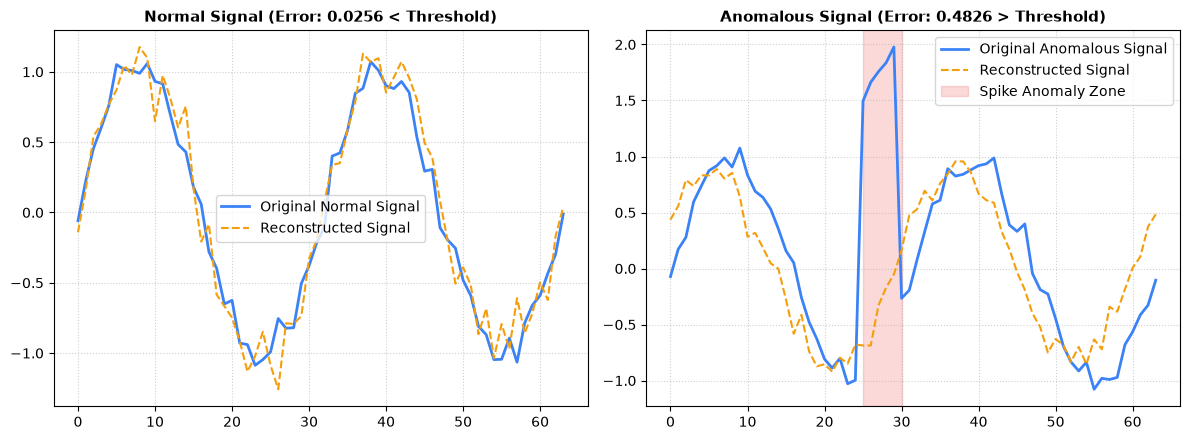

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

# Plot normal signal reconstruction
ax1.plot(test_normal, label='Original Normal Signal', color='#3B82F6', linewidth=2)
ax1.plot(reconstructed_batch[0], label='Reconstructed Signal', color='#F59E0B', linestyle='--', linewidth=1.5)
ax1.set_title(f"Normal Signal (Error: {errors[0]:.4f} < Threshold)", fontsize=11, fontweight='bold')
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.legend()

# Plot anomalous signal reconstruction
ax2.plot(test_anomalous, label='Original Anomalous Signal', color='#3B82F6', linewidth=2)
ax2.plot(reconstructed_batch[1], label='Reconstructed Signal', color='#F59E0B', linestyle='--', linewidth=1.5)
# Highlight anomaly coordinates
ax2.axvspan(25, 30, color='#EF4444', alpha=0.2, label='Spike Anomaly Zone')
ax2.set_title(f"Anomalous Signal (Error: {errors[1]:.4f} > Threshold)", fontsize=11, fontweight='bold')
ax2.grid(True, linestyle=':', alpha=0.6)
ax2.legend()

plt.tight_layout()
plt.show()
